In [1]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from src.visualizations import plot_experiment_results

In [2]:
results = pd.read_csv('../results/lsvt.csv')
df = results
# df

In [102]:
COLOR_PALETTE = ["#0cb2af", "#a1c65d", "#fac723", "#f29222", "#e95e50", "#936fac"]
COLORS = {
    "ORACLE": "#6c5d4e",
}
FONTSIZES = {
    "title": 14, 
    "xlabel": 12,
    "ylabel": 12
}

def get_oracle_mean_std(results: pd.DataFrame):
    oracle_mean = df[df["Approach"] == "Oracle"]["Accuracy"].mean()
    oracle_std = df[df["Approach"] == "Oracle"]["Accuracy"].std()
    return oracle_mean, oracle_std


def preprocess_results(df: pd.DataFrame):
    model_rename = {
        "LogisticRegression": "LR",
        "RandomForestClassifier": "RFC",
        "XGBClassifier": "XGB",
        "SVC": "SVC",
    }

    df = df.copy()

    df["base_estimator"] = df["base_estimator"].map(model_rename)

    df["k_best"] = df["k_best"].astype("Int64")

    df["estimator"] = df["base_estimator"] + "_" + df["k_best"].astype(str)

    df["Approach"] = np.where(
        df["Approach"] == "self_training", "ST_" + df["estimator"], df["Approach"]
    )

    return df


def make_scheme_labels(df, scheme_type):
    if scheme_type == "MCAR":
        missing_med = df.groupby("Scheme")["Missing_Percent"].median().round(1)
        return (
            df["Scheme"]
            + "\n(Missing="
            + df["Scheme"].map(missing_med).astype(str)
            + "%)"
        )

    if scheme_type == "MAR1":
        base = "MAR1\n$w$=" + df["w1"].astype(str) + " $b$=" + df["b1"].astype(str)
        missing_med = df.groupby(["w1", "b1"])["Missing_Percent"].median().round(1)
        med = df.set_index(["w1", "b1"]).index.map(missing_med)

    elif scheme_type == "MAR2":
        base = "MAR2\n$w$=" + df["w2"].astype(str) + " $b$=" + df["b2"].astype(str)
        missing_med = df.groupby(["w2", "b2"])["Missing_Percent"].median().round(1)
        med = df.set_index(["w2", "b2"]).index.map(missing_med)

    elif scheme_type == "MNAR":
        base = (
            "MNAR\n$w_x$="
            + df["wx"].astype(str)
            + " $w_y$="
            + df["wy"].astype(str)
            + " $b_y$="
            + df["by"].astype(str)
        )
        missing_med = (
            df.groupby(["wx", "wy", "by"])["Missing_Percent"].median().round(1)
        )
        med = df.set_index(["wx", "wy", "by"]).index.map(missing_med)
    return base + "\n(Missing=" + pd.Series(med, index=df.index).astype(str) + "%)"


METRICS_MAP = {"Balanced_Acc": "Balanced accuracy", "ROC_AUC": "ROC AUC"}


def boxplot_by_scheme(
    df: pd.DataFrame, metric: str, dataset_name: str, scheme_type: str
):
    oracle_mean, _ = get_oracle_mean_std(df)

    df = preprocess_results(df)
    df = df.dropna(subset="Scheme")
    df = df[df["Scheme"].str.startswith(scheme_type)]

    # Only first 4 comb for MNAR
    if scheme_type == "MNAR":
        first_4 = df[["wx", "wy", "by"]].drop_duplicates().head(4)
        df = df.merge(first_4, on=["wx", "wy", "by"])

    df["Scheme_label"] = make_scheme_labels(df, scheme_type)

    plt.figure(figsize=(11, 6))

    ax = sns.boxplot(
        data=df,
        x="Scheme_label",
        y=metric,
        hue="Approach",
        hue_order=[
            "naive",
            "label_propagation",
            "ST_LR_1",
            "ST_RFC_1",
            "ST_XGB_1",
            "ST_SVC_1",
        ],
        palette=COLOR_PALETTE,
        gap=0.1,
    )
    plt.legend(loc="lower left")
    legend = ax.get_legend()
    new_labels = ["Naive", "Label Propagation", "ST LR", "ST RFC", "ST XGB", "ST SVC"]
    for text, label in zip(legend.texts, new_labels):
        text.set_text(label)
    legend.set_title("Approach")

    plt.axhline(
        y=oracle_mean,
        linestyle="--",
        color="#6c5d4e",
        alpha=0.7,
        label=f"Oracle mean ({oracle_mean:.3f})",
        zorder=0,
    )
    plt.ylabel(ylabel=METRICS_MAP.get(metric, metric) + " (test data)", fontsize=FONTSIZES["ylabel"])
    plt.xlabel("Missing mechanism", fontsize=FONTSIZES["ylabel"])
    plt.title(
        f"Comparison of approaches - {METRICS_MAP.get(metric, metric)} (Dataset: {dataset_name})",
        fontsize=FONTSIZES["title"],
    )
    plt.tight_layout()

### MCAR

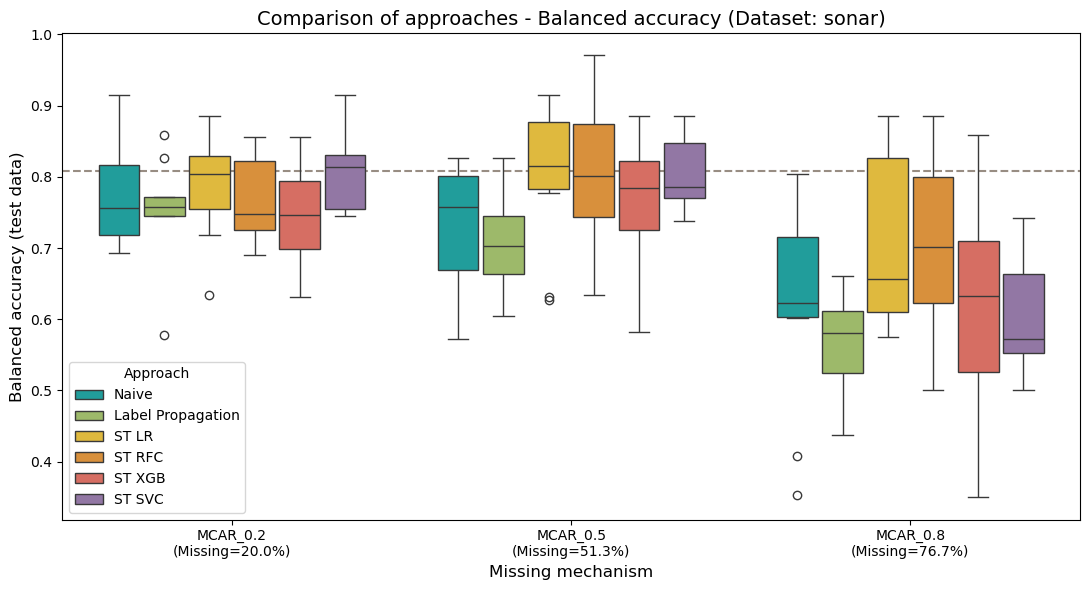

In [103]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MCAR')

### MAR1

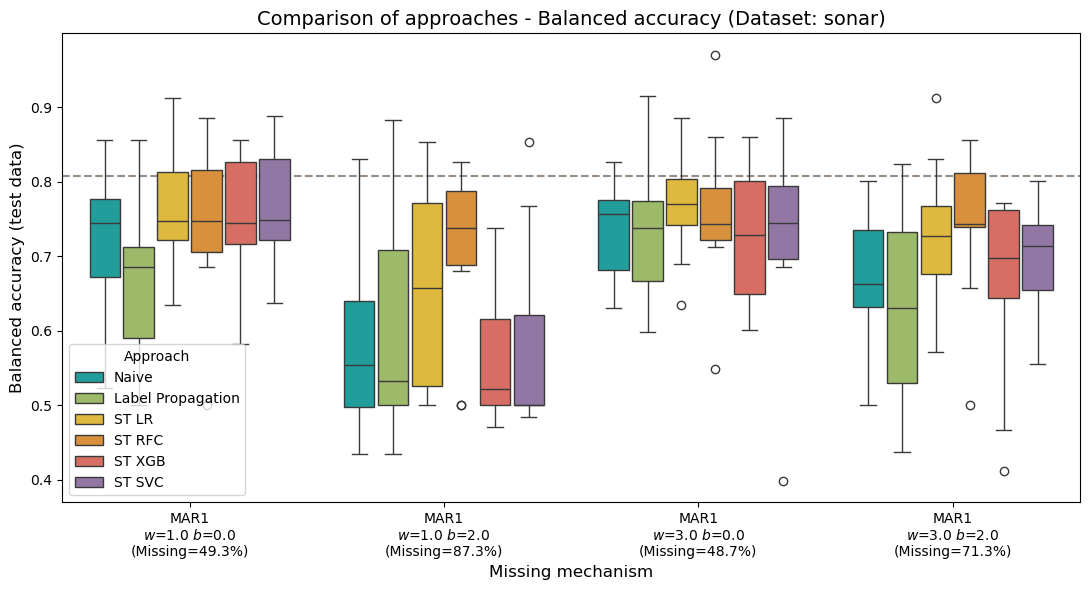

In [104]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MAR1')

### MAR2

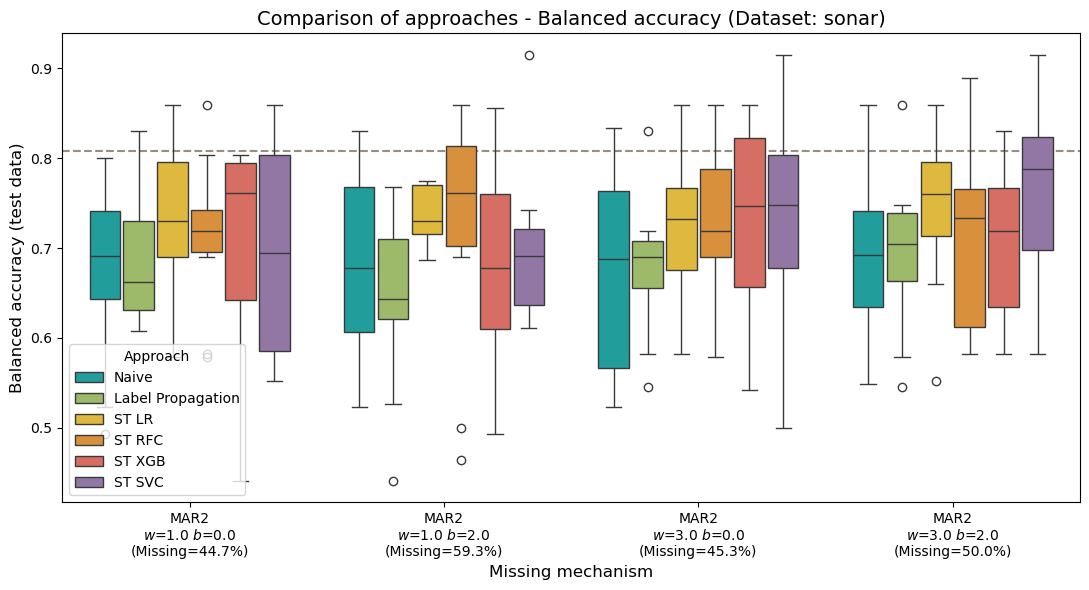

In [105]:
boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MAR2')

### MNAR

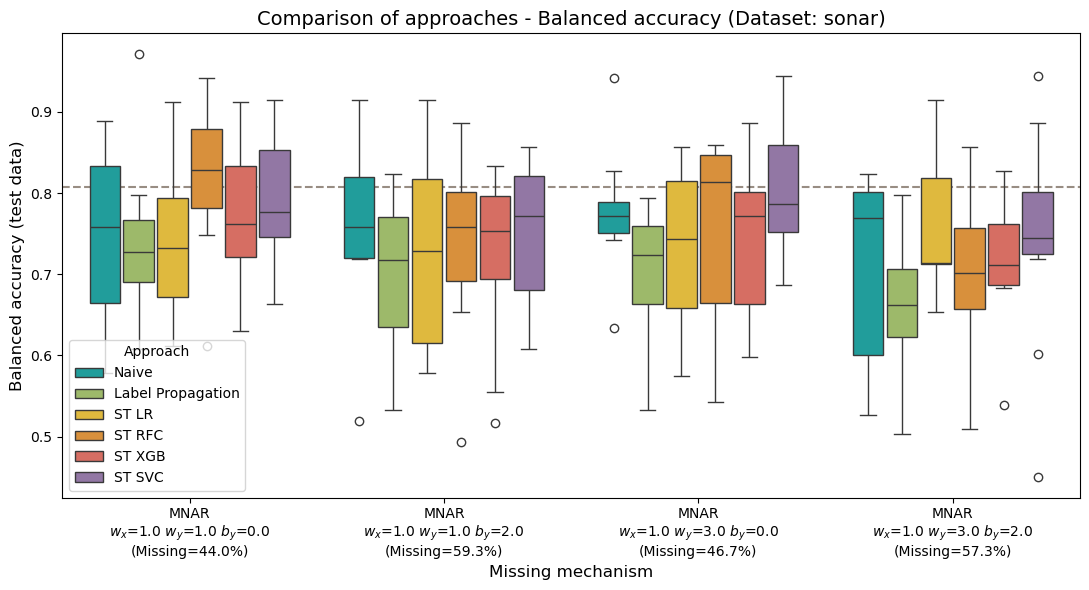

In [106]:

boxplot_by_scheme(results, 'Balanced_Acc', 'sonar', 'MNAR')